# NHANES 2021-2023: Sleep and Blood Pressure
## Step 2: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_clean = pd.read_csv('../Data/nhanes_clean.csv')
print(df_clean.shape)

df_clean.head()

(5999, 8)


,SEQN,age,sex,bmi,systolic_bp,diastolic_bp,hypertension_diagnosis,sleep_hours
0,130378.0,43.0,1.0,27.0,135.0,98.0,1.0,9.5
1,130379.0,66.0,1.0,33.5,121.0,84.0,1.0,9.0
2,130380.0,44.0,2.0,29.7,111.0,79.0,2.0,8.0
3,130386.0,34.0,1.0,30.2,110.0,72.0,2.0,7.5
4,130387.0,68.0,2.0,42.6,143.0,76.0,1.0,3.0


### Plotting Sleep Hours

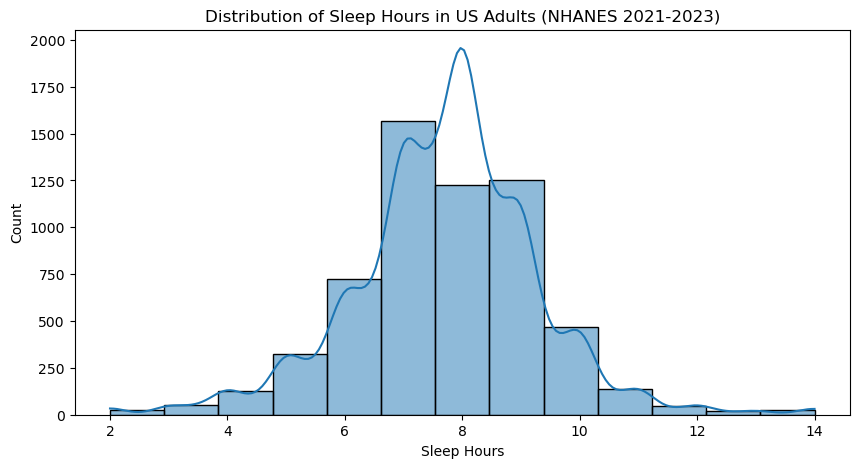

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['sleep_hours'], bins=13, kde=True)
plt.title('Distribution of Sleep Hours in US Adults (NHANES 2021-2023)')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')
plt.show()

### Plotting Systolic BP

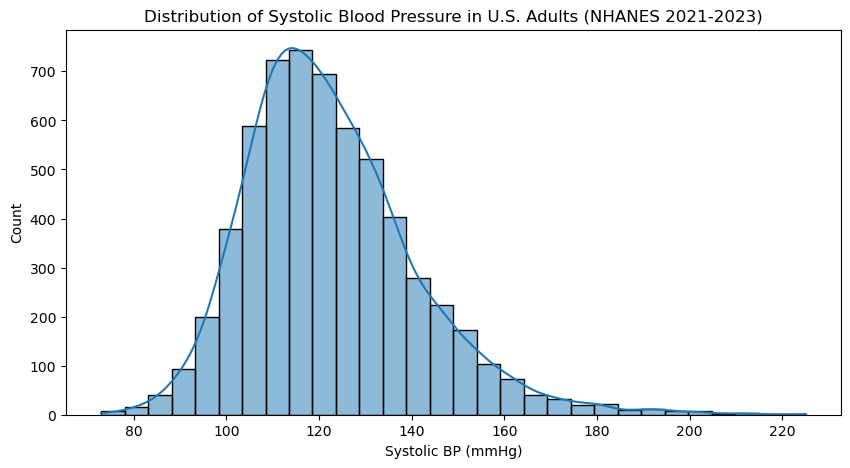

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['systolic_bp'], bins=30, kde=True)
plt.title('Distribution of Systolic Blood Pressure in U.S. Adults (NHANES 2021-2023)')
plt.xlabel('Systolic BP (mmHg)')
plt.ylabel('Count')
plt.show()

### Relationship Between BP & Sleep (Scatterplot)

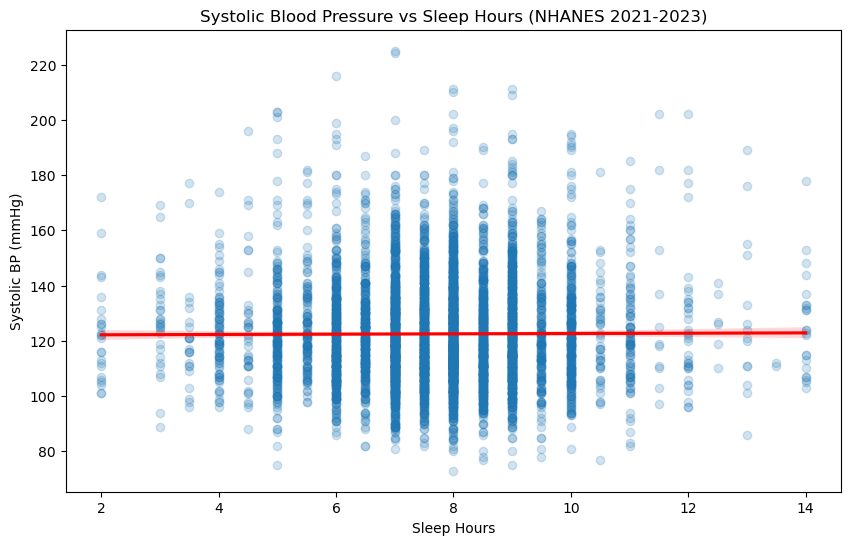

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='sleep_hours', y='systolic_bp', scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title('Systolic Blood Pressure vs Sleep Hours (NHANES 2021-2023)')
plt.xlabel('Sleep Hours')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Average BP By Sleep Group (Boxplot)

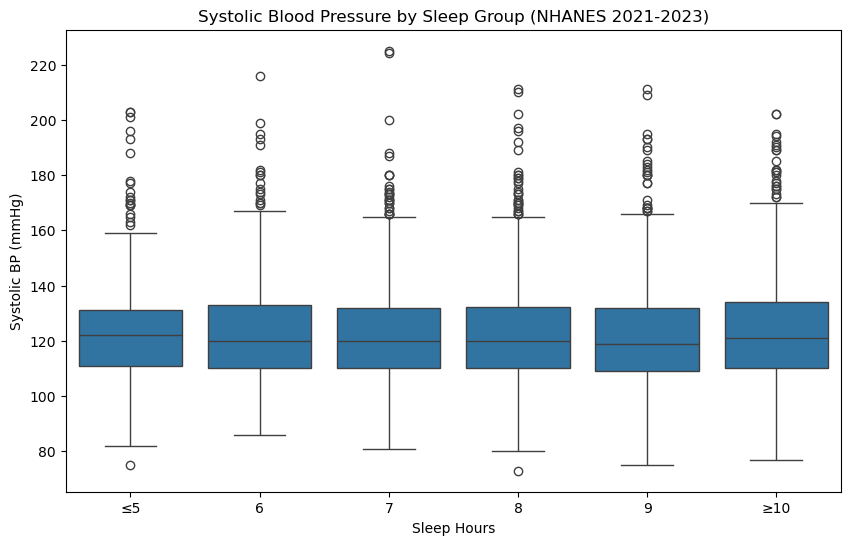

In [12]:
df_clean['sleep_group'] = pd.cut(df_clean['sleep_hours'], 
                                  bins=[0, 5, 6, 7, 8, 9, 14],
                                  labels=['≤5', '6', '7', '8', '9', '≥10'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='sleep_group', y='systolic_bp')
plt.title('Systolic Blood Pressure by Sleep Group (NHANES 2021-2023)')
plt.xlabel('Sleep Hours')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Age vs. BP

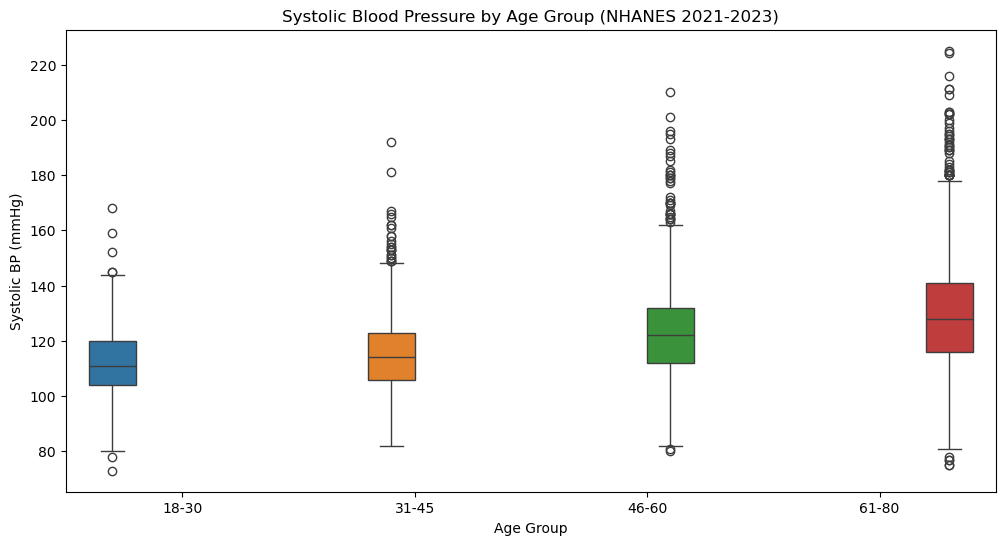

In [13]:
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[17, 30, 45, 60, 80],
                                labels=['18-30', '31-45', '46-60', '61-80'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='age_group', y='systolic_bp', hue='age_group')
plt.title('Systolic Blood Pressure by Age Group (NHANES 2021-2023)')
plt.xlabel('Age Group')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Sleep vs. Age

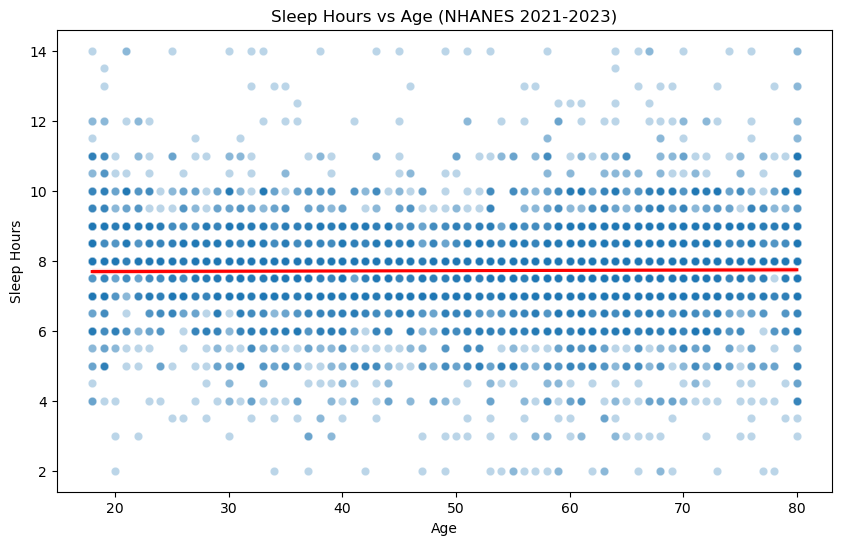

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='age', y='sleep_hours', alpha=0.3)
sns.regplot(data=df_clean, x='age', y='sleep_hours', 
            scatter=False, line_kws={'color': 'red'})
plt.title('Sleep Hours vs Age (NHANES 2021-2023)')
plt.xlabel('Age')
plt.ylabel('Sleep Hours')
plt.show()

### Sleep vs BP Separated by Age Group

<Figure size 1200x800 with 0 Axes>

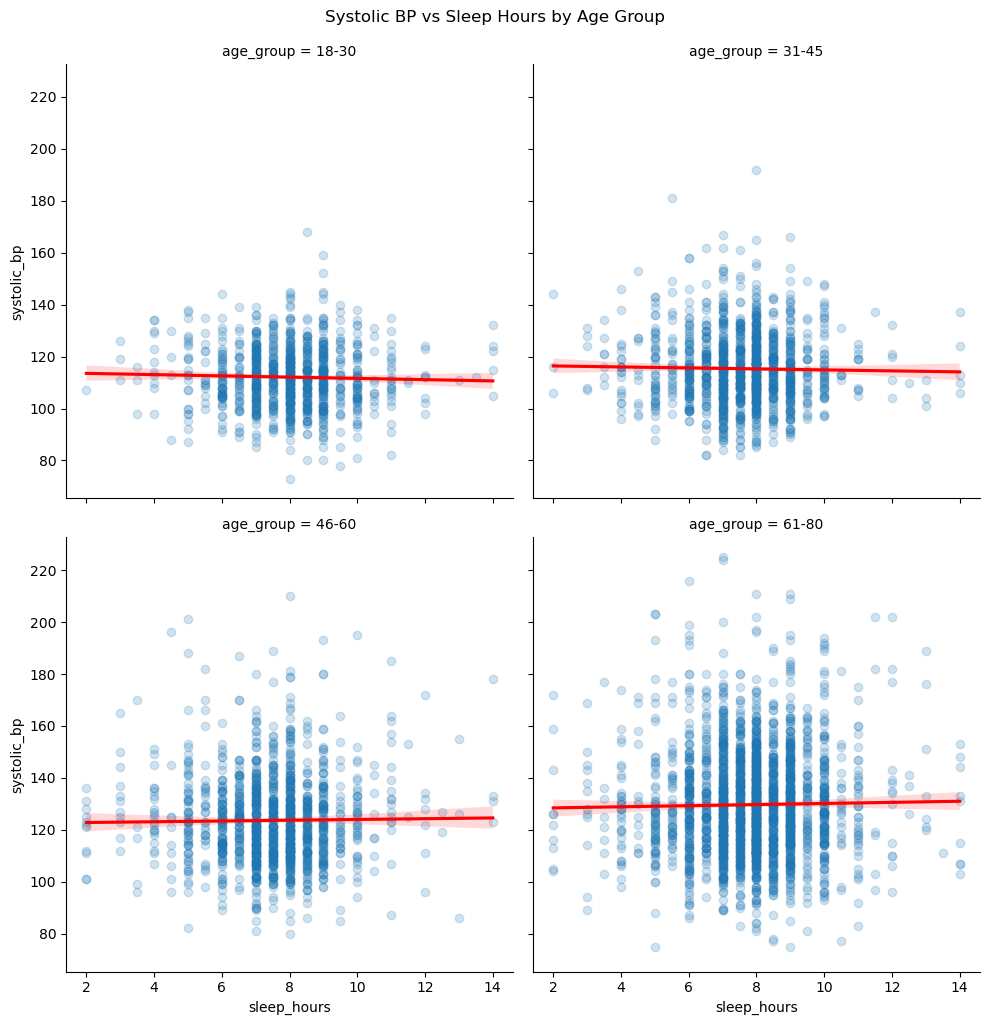

In [14]:
plt.figure(figsize=(12,8))
sns.lmplot(data=df_clean, x='sleep_hours', y='systolic_bp', col='age_group', col_wrap=2, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.suptitle('Systolic BP vs Sleep Hours by Age Group', y=1.02)
plt.show()

### Next Steps
- Sex vs Systolic BP
- Sex vs Sleep Hours
- BMI vs Systolic BP
- BMI vs Sleep Hours
- Correlation Heatmap of all vars together
- Hypertension visualization (what % of sample has it)

### Sex vs. Systolic BP

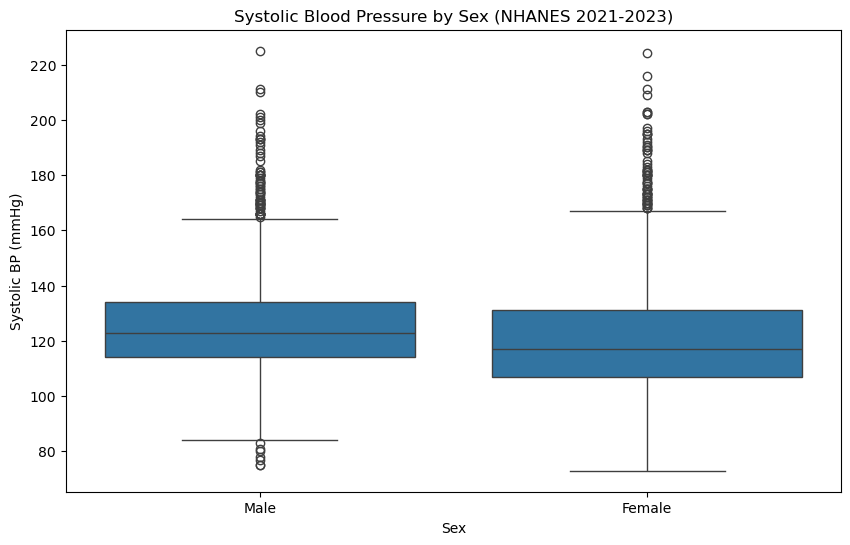

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='sex', y='systolic_bp')
plt.xticks([0, 1], ['Male', 'Female'])
plt.title('Systolic Blood Pressure by Sex (NHANES 2021-2023)')
plt.xlabel('Sex')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Sex vs. Sleep Hours

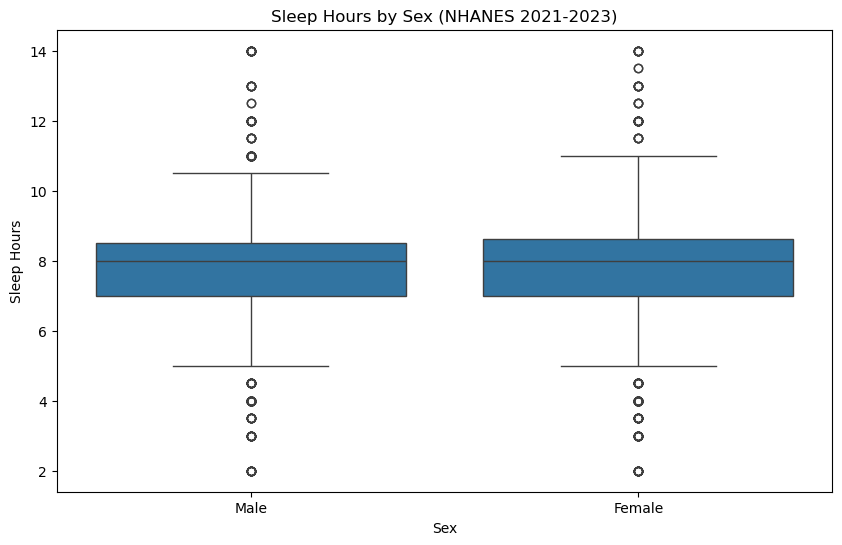

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='sex', y='sleep_hours')
plt.xticks([0, 1], ['Male', 'Female'])
plt.title('Sleep Hours by Sex (NHANES 2021-2023)')
plt.xlabel('Sex')
plt.ylabel('Sleep Hours')
plt.show()

### BMI vs. Systolic BP

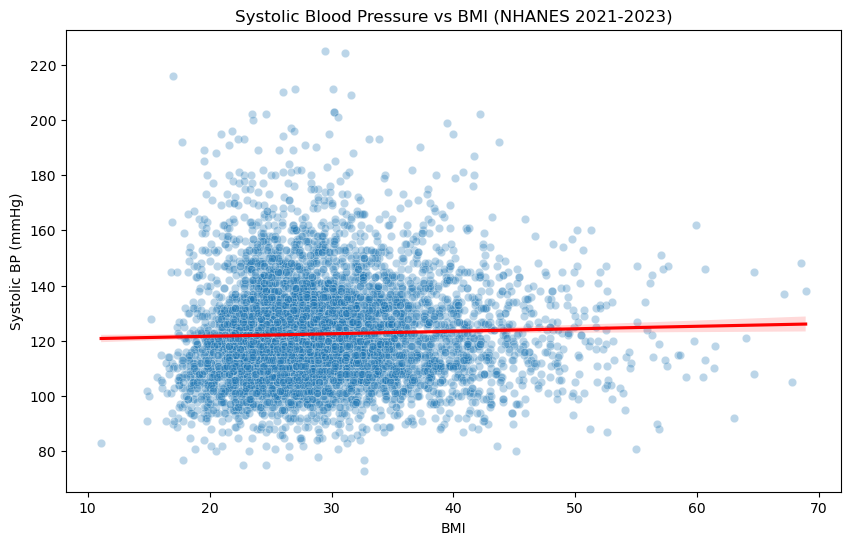

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='bmi', y='systolic_bp', alpha=0.3)
sns.regplot(data=df_clean, x='bmi', y='systolic_bp', 
            scatter=False, line_kws={'color': 'red'})
plt.title('Systolic Blood Pressure vs BMI (NHANES 2021-2023)')
plt.xlabel('BMI')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Sleep Hours vs. BMI

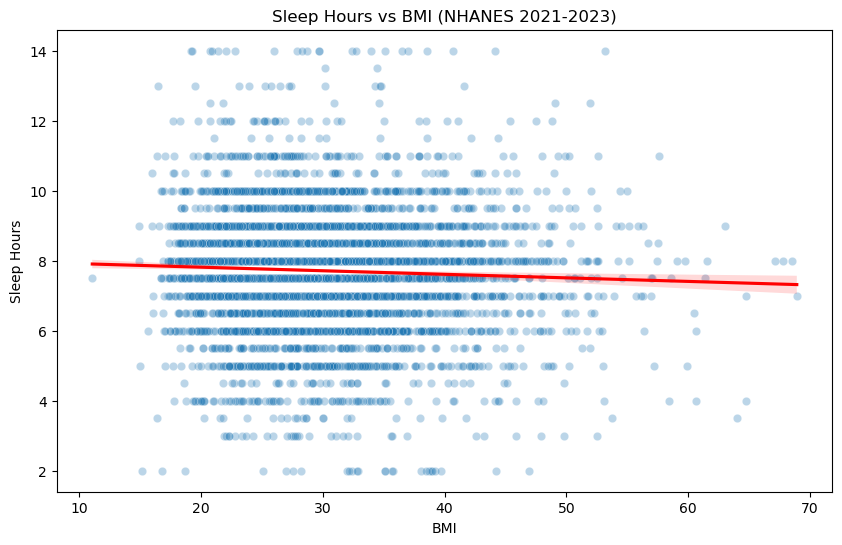

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='bmi', y='sleep_hours', alpha=0.3)
sns.regplot(data=df_clean, x='bmi', y='sleep_hours',
            scatter=False, line_kws={'color': 'red'})
plt.title('Sleep Hours vs BMI (NHANES 2021-2023)')
plt.xlabel('BMI')
plt.ylabel('Sleep Hours')
plt.show()

### Correlation Heatmap of All Variables

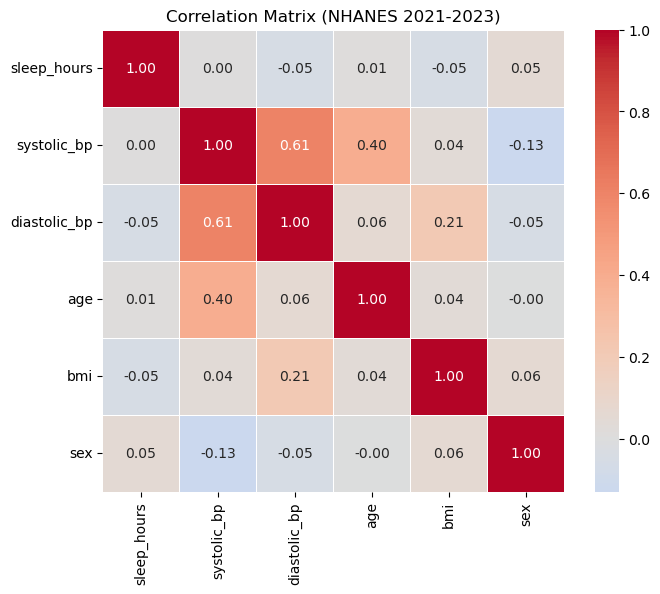

In [8]:
plt.figure(figsize=(8, 6))
corr = df_clean[['sleep_hours', 'systolic_bp', 'diastolic_bp', 'age', 'bmi', 'sex']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix (NHANES 2021-2023)')
plt.show()

### Hypertension Visualization

hypertension_diagnosis
2.0    3819
1.0    2180
Name: count, dtype: int64
hypertension_diagnosis
2.0    0.64
1.0    0.36
Name: proportion, dtype: float64


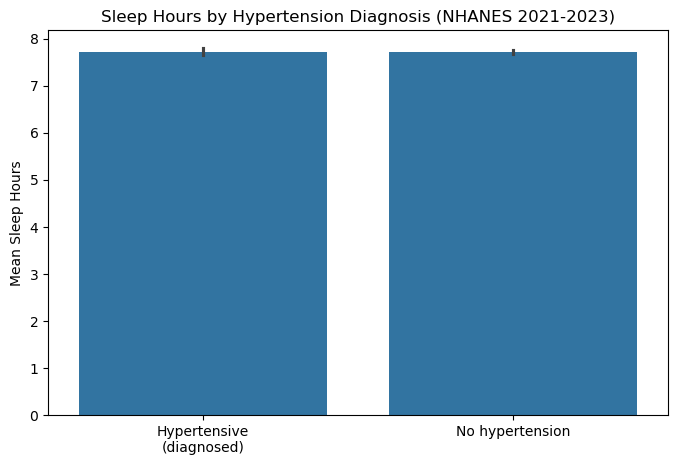

In [10]:
# Hypertension breakdown
print(df_clean['hypertension_diagnosis'].value_counts())
print(df_clean['hypertension_diagnosis'].value_counts(normalize=True).round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='hypertension_diagnosis', y='sleep_hours',
            errorbar='ci')
plt.xticks([0, 1], ['Hypertensive\n(diagnosed)', 'No hypertension'])
plt.title('Sleep Hours by Hypertension Diagnosis (NHANES 2021-2023)')
plt.xlabel('')
plt.ylabel('Mean Sleep Hours')
plt.show()

## EDA Summary

Sample: 5,999 U.S. adults, NHANES 2021-2023

Key findings:
- Sleep hours are approximately normally distributed, peaking at 7-8 hours
- Systolic BP is right-skewed, peaking around 120 mmHg
- No meaningful raw correlation between sleep and systolic BP (r = 0.00)
- Age is the strongest predictor of systolic BP (r = 0.40), with a marked increase after age 45
- BMI shows a slight positive association with BP and slight negative association with sleep — potential confounder
- Sex shows small but expected effect: males have slightly higher BP
- Hypertensive and non-hypertensive groups show nearly identical mean sleep hours (7.7)
- The sleep-BP relationship appears to vary by age group — hint of an interaction effect
- Self-reported sleep may lack sensitivity to detect true associations

Next step: Linear and logistic regression controlling for age, sex, and BMI